# `06-workflow.ipynb`

In [2]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

llm = init_chat_model('gpt-4.1-mini')

## Prompt Chaining

- 매우 잘 정리된 업무 순서가 있을 경우 사용
- 이전 노드에서 처리한 내용을 `state` 에 담아 다음 노드로 전송

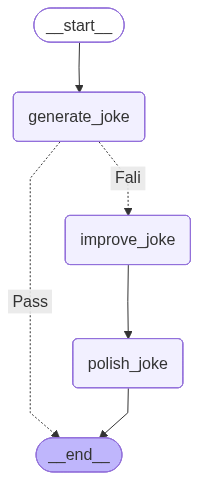

{'topic': '랭체인',
 'joke': "왜 랭체인 언어모델은 항상 멋지게 차려입고 다닐까?  \n— 언제나 '체인'을 잇는 게 중요하니까!"}

In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
# 그림 보는 용
from IPython.display import Image, display


# Graph State
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'주제 {state['topic']}에 관련된 짧은 농담 생성')
    return {'joke': msg.content}


def improve_joke(state: State):
    msg = llm.invoke(f'말장난을 추가해서 아래 농담을 더 재밌게 만들어보자.\n {state['joke']}')
    return {'improved_joke': msg.content}


def polish_joke(state: State):
    msg = llm.invoke(f'아래 농담을 쩔게 뒤틀어 보자. \n {state['improved_joke']}')
    return {'final_joke': msg.content}


# Router
def check_punchline(state: State):
    # ? 나 ! 없으면, 농담을 improve 하고, 있으면 그대로 진행
    if '?' in state['joke'] or '!' in state['joke']:
        return 'Pass'
    else:
        return 'Fail'
    

workflow = StateGraph(State)

# 조립
workflow.add_node(generate_joke)
workflow.add_node(improve_joke)
workflow.add_node(polish_joke)

workflow.add_edge(START, 'generate_joke')
workflow.add_conditional_edges(
    'generate_joke',
    check_punchline,
    {
        'Pass': END,
        'Fali': 'improve_joke'
    }
)
workflow.add_edge('improve_joke', 'polish_joke')
workflow.add_edge('polish_joke', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


graph.invoke({'topic': '랭체인'})

## Parallelization (병렬화) (비동기)
- 여러 node(llm)이 동시에 작업을 진행
- 뭐가 먼저 끝날지 알 수 없음
- 하위 태스크를 동시에 진행시켜서 속도 up
- 같은 태스크를 여러번 동시에 돌려서 신뢰성 확보

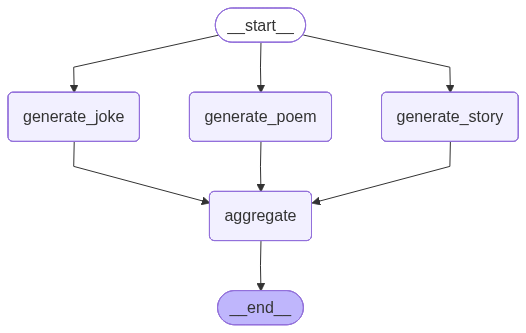

{'topic': '봄',
 'joke': '왜 봄이 언제나 행복할까요?  \n꽃길만 걸어서요! 🌸😄',
 'story': '봄, the gentle harbinger of life and color, arrived quietly in the small village nestled between misty mountains. After a long, harsh winter, the air was filled with the soft scent of blooming flowers and the cheerful songs of returning birds. \n\nIn this village lived a young girl named Hana, whose heart longed for the vibrancy of spring. Every morning, she would run outside to feel the warmth of the sun on her face and to watch the cherry blossoms begin to unfurl their delicate petals. The trees, once bare and silent, now danced with pink and white blossoms, painting the landscape with hope and renewal.\n\nOne particular morning, Hana discovered a tiny sprout pushing through the thawed earth by the riverbank. She knelt down and gently cupped the fragile plant in her hands. It was a symbol of new beginnings, and she promised to care for it every day. As days turned into weeks, the sprout blossomed into a beautiful fl

In [11]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    output: str


# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'Write a joke about {state['topic']}')
    return {'joke': msg.content}


def generate_story(state: State):
    msg = llm.invoke(f'Write a story about {state['topic']}')
    return {'story': msg.content}


def generate_poem(state: State):
    msg = llm.invoke(f'Write a poem about {state['topic']}')
    return {'poem': msg.content}


def aggregate(state: State):
    output = f"""농담, 이야기, 시
Joke: {state['joke']} `
Story: {state['story']}
Poem: {state['poem']}
"""
    return {'output': output}


workflow = StateGraph(State)
workflow.add_node(generate_joke)
workflow.add_node(generate_poem)
workflow.add_node(generate_story)
workflow.add_node(aggregate)

workflow.add_edge(START, 'generate_joke')
workflow.add_edge(START, 'generate_poem')
workflow.add_edge(START, 'generate_story')
workflow.add_edge('generate_joke', 'aggregate')
workflow.add_edge('generate_poem', 'aggregate')
workflow.add_edge('generate_story', 'aggregate')
workflow.add_edge('aggregate', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({'topic': '봄'})

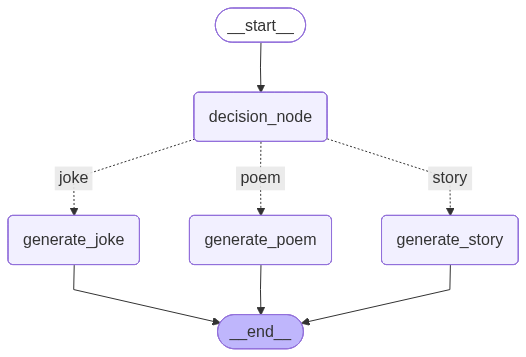

c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Route(step='joke'), input_type=Route])
  return self.__pydantic_serializer__.to_python(


{'input': '심심해',
 'decision': 'joke',
 'output': '심심할 때, 이렇게 생각해보세요:\n\n“만약 시간도 주식처럼 팔렸다면, ‘심심한 시간’은 아마도 시세가 급락해서 전 세계가 사재기했을 거야. 그래서 지금 우리에게 남은 건 고급스러운 ‘빈둥거림’이라는 한정판 주식뿐이지!”\n\n고급스러운 빈둥거림, 오늘은 나만의 주식 포트폴리오에 투자해볼까요? 😎'}

In [15]:
from typing import Literal
from langchain.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field


class State(TypedDict):
    input: str
    decision: str
    output: str


# Router 에서 사용할 LLM이 쓸 structured output
# {'step': 'poem' | 'story' | 'joke'}
class Route(BaseModel):
    # step 이란 필드는 3개중 하나지만, 필수(...)고 설명은 ~~하다
    step: Literal['poem', 'story', 'joke'] = Field(..., description='next step in routing process')

router_llm = llm.with_structured_output(Route)


# state['decision'] 을 결정하는 Node
def decision_node(state: State):
    result = router_llm.invoke(
        [
            SystemMessage(content='사용자 요청에 따라 story, joke, poem 을 선택'),
            HumanMessage(content=state['input'])
        ]
    )
    return {'decision': result.step}


def generate_joke(state: State):
    msg = llm.invoke([
        SystemMessage(content='아주 기발하되 고급스러운 유머를 만들어야 함'),
        HumanMessage(content=state['input'])
    ])
    return {'output': msg.content}


def generate_story(state: State):
    msg = llm.invoke(state['input'])
    return {'output': msg.content}


def generate_poem(state: State):
    msg = llm.invoke(state['input'])
    return {'output': msg.content}


# Router
def route_decision(state: State):
    return state['decision']


workflow = StateGraph(State)
workflow.add_node(decision_node)
workflow.add_node(generate_joke)
workflow.add_node(generate_poem)
workflow.add_node(generate_story)

workflow.add_edge(START, 'decision_node')
workflow.add_conditional_edges(
    'decision_node',
    route_decision,
    {
        'joke': 'generate_joke',
        'story': 'generate_story',
        'poem': 'generate_poem'
    }
)
workflow.add_edge('generate_joke', END)
workflow.add_edge('generate_story', END)
workflow.add_edge('generate_poem', END)
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({'input': '심심해'})

## Orchestrator - Worker
- 태스크를 서브태스크로 쪼갬
- 해당 서브태스크를 담당하는 워커에게 분배
- 모든 서브태스크들의 output을 최종 결과로 정리

In [18]:
from typing import Annotated, List
from pydantic import BaseModel, Field

# Structured Output 용 Model 생성 (계획수립용)
class Section(BaseModel):
    name: str = Field(
        ...,
        description='보고서내 해당 섹션명'
    )
    description: str = Field(
        ...,
        description='해당 섹션에서 다룰 주요 주제 및 개념에 대한 개요'
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        ...,
        description='리포트의 섹션들'
    )

planner_llm = llm.with_structured_output(Sections)
planner_llm.invoke('LLM 스케일링 법칙에 대한 레포트 작성해줘')

c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sections(sections=[Sectio...약을 제시한다.')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


Sections(sections=[Section(name='서론', description='LLM 스케일링 법칙의 중요성과 개념에 대해 간략히 소개한다.'), Section(name='LLM 스케일링 법칙 개요', description='스케일링 법칙이란 무엇이며, LLM에 어떻게 적용되는지 설명한다.'), Section(name='스케일링 법칙의 수학적 모델', description='파라미터 수, 데이터 양, 계산량 간의 관계를 수학적으로 표현한다.'), Section(name='실험 및 관찰 결과', description='스케일링 법칙에 따른 모델 성능 변화와 실제 연구 사례를 정리한다.'), Section(name='적용과 한계', description='스케일링 법칙의 적용 범위와 한계점, 그리고 현실적인 고려사항에 대해 논의한다.'), Section(name='미래 전망', description='향후 LLM 개발과 스케일링 법칙 연구 방향을 전망한다.'), Section(name='결론', description='LLM 스케일링 법칙의 의의와 요약을 제시한다.')])

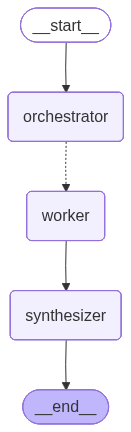

c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sections(sections=[Sectio...및 리포트 요약')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


In [28]:
import operator
from langgraph.types import Send  # 유동적으로 worker 노드를 실행

from langgraph.graph import MessagesState


# Graph State
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections : Annotated[list, operator.add]
    final_report: str


# Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    report_sections = planner_llm.invoke(
        [
            SystemMessage(content='Generate a plan for report.'),
            HumanMessage(content=f'Here is the report topic: {state['topic']}'),
        ]
    )

    return {'sections': report_sections.sections}


def worker(state: WorkerState):
    section = llm.invoke(
        [
            SystemMessage(content='제공된 name 과 description에 따라 보고서 섹션을 작성해라. 각 섹션 앞에는 서두를 넣지 말고, md 형식으로 작성.'),
            HumanMessage(content=f'섹션 name: {state['section'].name} \n섹션 description: {state['section'].description}'),
        ]
    )
    return {'completed_sections': [section.content]}


def synthesizer(state: State):
    # 단순히 worker 들의 결과 합치기
    completed_sections = state['completed_sections']
    final_report = '\n\n ------------- \n\n'.join(completed_sections)
    return {'final_report': final_report}


# Router
def assign_workers(state: State):
    plan = []
    for s in state['sections']:
        plan.append(Send('worker', {'section': s}))
    
    return plan


# Graph
workflow = StateGraph(State)

workflow.add_node(orchestrator)
workflow.add_node(worker)
workflow.add_node(synthesizer)

workflow.add_edge(START, 'orchestrator')
workflow.add_conditional_edges(
    'orchestrator',
    assign_workers,
    ['worker']
)

workflow.add_edge('worker', 'synthesizer')
workflow.add_edge('synthesizer', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({'topic': 'LLM 스케일링 법칙에 대한 리포트 작성'})

In [29]:
from IPython.display import Markdown
Markdown(result['final_report'])

# 서론

대규모 언어 모델(LLM)의 스케일링 법칙은 모델의 크기, 데이터 양, 계산 자원의 증가가 성능 향상에 미치는 관계를 정량적으로 제시하는 원리이다. 이 법칙은 인공지능 연구와 응용 분야에서 모델 설계와 개발 전략을 수립하는 데 중요한 지침 역할을 한다. 본 리포트는 LLM 스케일링 법칙의 개념과 그 중요성을 살펴보고, 이를 기반으로 향후 모델 최적화 및 효율적인 자원 배분 방안을 모색하는 것을 목적으로 한다.

 ------------- 

# LLM 스케일링 법칙 개요

스케일링 법칙은 대형 언어 모델(LLM)의 성능이 모델 크기, 학습 데이터 양, 계산 자원 등 다양한 요소에 따라 체계적으로 향상된다는 원리를 의미한다. 이러한 법칙은 모델을 확장하면서 발생하는 성능 변화 패턴을 정량적으로 분석함으로써, 향후 연구 방향성과 자원 배분에 중요한 가이드라인을 제공한다.

스케일링 법칙의 역사는 2010년대 후반, 딥러닝 모델의 규모와 성능이 빠르게 증가하면서 본격적으로 주목받기 시작했다. 초기에는 이미지 인식 분야에서 규모 확장에 따른 성능 향상이 관찰되었고, 이후 자연어 처리 분야에서 대형 언어 모델이 등장하며 언어 모델링 정확도와 생성 능력이 눈에 띄게 개선되는 현상이 발견되었다.

주요 연구 사례로는 OpenAI가 발표한 "Scaling Laws for Neural Language Models" (Kaplan et al., 2020) 연구가 있다. 이 논문에서는 모델 파라미터 수, 데이터 크기, 연산량이 늘어남에 따라 언어 모델의 손실 함수 값이 일정한 법칙에 따라 감소한다는 사실을 실험적으로 입증했다. 또한 Google Research의 "Scaling Laws for Transfer" 연구에서는 스케일링이 사전학습된 모델의 전이 학습 성능에도 긍정적인 영향을 미침을 보여주었다.

이러한 연구들은 LLM 개발자들이 모델 크기와 학습 자원 간의 균형을 맞추고, 효율적인 학습 전략을 수립하는 데 중요한 이론적 근거를 제공하며, 현재 인공지능 커뮤니티에서 활발히 활용되고 있다.

 ------------- 

## 스케일링 법칙의 주요 요소

스케일링 법칙은 인공지능 모델의 성능 향상에 있어 핵심적인 역할을 하는 다양한 요소들에 의해 좌우된다. 대표적인 요소로는 모델 크기, 데이터 양, 계산 자원이 있으며, 각각의 요소가 스케일링에 미치는 영향은 다음과 같다.

### 1. 모델 크기
모델 크기는 주로 파라미터 수로 측정되며, 이는 모델이 학습할 수 있는 표현력과 복잡성에 직결된다. 파라미터 수가 증가함에 따라 모델의 용량이 커지고, 이는 더 복잡한 패턴과 관계를 학습할 수 있도록 한다. 그러나 무작정 크기를 키우는 것은 계산 비용과 과적합 위험을 동반하므로, 적절한 균형이 중요하다.

### 2. 데이터 양
풍부한 데이터 양은 모델이 일반화 능력을 높이는 데 필수적이다. 충분한 데이터가 뒷받침되지 않으면 큰 모델도 과적합에 빠질 수 있으며, 데이터 다변화 및 품질 또한 성능에 중요한 영향을 미친다. 스케일링 법칙에서는 모델 크기가 확대될수록 데이터 요구량 또한 비례하여 늘어나야 한다는 점을 강조한다.

### 3. 계산 자원
대규모 모델과 방대한 데이터를 효과적으로 학습하기 위해서는 막대한 계산 자원이 필요하다. GPU, TPU 등의 고성능 하드웨어와 효율적인 분산 학습 환경이 이 요소에 해당한다. 계산 자원의 한계는 모델 크기 및 데이터 확장성에 직접적인 제약 요인으로 작용한다.

이처럼 스케일링 법칙의 주요 요소들은 상호 유기적으로 작용하며, 최적의 성능 달성을 위해서는 이들 요소 간의 균형 있는 조정이 필수적이다.

 ------------- 

# 스케일링 법칙의 적용 사례

스케일링 법칙은 대규모 언어 모델(LLM) 개발과 활용에서 모델 성능 향상과 자원 투입 간의 관계를 체계적으로 이해하는 데 중요한 역할을 한다. 다음은 실제 사례들을 통해 스케일링 법칙이 어떻게 적용되고 있는지를 살펴본다.

## 1. GPT 시리즈 개발 과정

OpenAI의 GPT (Generative Pre-trained Transformer) 시리즈는 스케일링 법칙을 기반으로 모델 크기와 학습 데이터 양을 점진적으로 확장하면서 성능을 크게 향상시켰다. 예를 들어, GPT-3는 1750억 개의 파라미터를 보유하고, 방대한 인터넷 텍스트 데이터로 학습되어 다양한 자연어 처리 작업에서 뛰어난 성능을 보였다. 이를 통해 단순히 모델 크기 증가가 성능 향상에 직접적으로 기여함을 입증하였다.

## 2. 비용과 성능의 균형 최적화

딥마인드(DeepMind)의 연구에서는 스케일링 법칙을 이용해 특정 자원 제한 내에서 최적의 모델 크기와 학습 데이터 규모를 결정하였다. 예를 들어, 동일한 학습 비용 대비 더 큰 모델을 학습시키면 더 나은 일반화 성능을 얻을 수 있음을 확인했다. 이를 통해 실무에서는 예산 내에서 최대 효율을 내는 스케일링 전략을 수립할 수 있다.

## 3. 멀티태스크 학습과 전이학습

스케일링 법칙에 따르면 모델 규모가 커질수록 다양한 작업에서 범용적인 표현을 학습할 가능성이 높아진다. 실제로 대형 LLM들은 소규모 데이터셋이나 특정 도메인의 태스크로 파인튜닝할 때, 기본적으로 더 우수한 전이 학습 능력을 보였다. 예를 들어, 원격 진단, 법률 문서 처리 등 특화된 분야에서도 큰 모델을 활용한 전이가 효과적으로 이루어졌다.

## 4. 효율적인 하드웨어 및 병렬 처리 설계

대형 모델 학습에는 막대한 연산 능력이 요구되므로, 스케일링 법칙에 따른 모델 확장은 하드웨어 설계에도 영향을 미친다. 실제 사례로 페이스북 AI 연구소(FAIR)는 대규모 모델 학습을 위해 분산 학습과 효율적 병렬처리 기법을 개발했으며, 이를 통해 모델 크기 확장에 따른 학습 시간과 비용을 최소화하는 전략을 수립하였다.

이와 같이, 스케일링 법칙은 LLM 개발 전반에서 모델 크기, 데이터 양, 학습 및 추론 효율성 간의 균형을 맞추는 데 핵심적인 지침을 제공하며, 실제 산업 및 연구 현장에서 다양하게 적용되고 있다.

 ------------- 

## 스케일링 법칙의 한계와 도전 과제

스케일링 법칙은 인공지능 모델의 성능 향상을 예측하고 가이드하는 중요한 원칙으로 자리잡았다. 그러나 이러한 법칙에도 명확한 한계가 존재하며, 이를 극복하기 위한 다양한 연구가 요구되고 있다.

첫째, 스케일링 법칙은 주로 대규모 데이터와 연산 자원에 의존하는 경향이 강하다. 이는 자원 제약이 있는 환경에서는 적용이 어려우며, 무한정 자원을 늘려가는 방식이 지속 가능하지 않다는 점에서 현실적인 한계로 작용한다.

둘째, 스케일링 법칙은 모델 규모가 커질수록 성능이 일정한 형태로 개선된다는 가정을 기반으로 하지만, 특정 도메인이나 태스크에서는 비선형적이거나 예외적인 성능 변화를 보이는 경우도 있다. 따라서 모델의 일반화 능력과 효율성 향상을 위한 정밀한 조정이 필요하다.

셋째, 대규모 모델에서 발생하는 계산 비용과 환경적 영향 문제 역시 심각한 도전 과제이다. 막대한 에너지 소비와 탄소 배출은 지속 가능한 AI 개발을 위해 반드시 해결해야 하는 문제로 부각되고 있다.

이러한 한계들을 극복하기 위한 연구 방향으로는, 효율적인 모델 구조 설계, 데이터 효율성 증대, 그리고 소규모 자원으로도 높은 성능을 낼 수 있는 경량화 기술 개발 등이 활발히 진행되고 있다. 또한, 스케일링 법칙의 수학적 기초 및 적용 범위를 확장하여 더 다양한 조건과 환경에서의 성능 예측력을 강화하는 연구도 중요하다.

결론적으로, 스케일링 법칙은 AI 발전에 중요한 지침이지만, 그 한계를 명확히 인식하고 이를 해결하기 위한 다각적인 접근과 지속적인 연구가 필요하다.

 ------------- 

## 미래 전망 및 결론

LLM 스케일링 법칙은 대규모 언어 모델의 성능 향상에 핵심적인 역할을 수행하며, 앞으로도 더욱 중요한 발전 동력이 될 것으로 예상된다. 향후에는 모델의 파라미터 수와 학습 데이터 규모뿐만 아니라, 효율적인 학습 알고리즘, 모델 아키텍처 최적화, 하드웨어 혁신 등이 복합적으로 작용하여 스케일링 법칙의 적용 범위와 정확도가 확대될 것이다. 특히, 지속 가능한 연산 자원 활용과 윤리적 AI 개발 측면에서도 스케일링 법칙을 기반으로 한 연구가 중요해질 전망이다.

인공지능 분야에 미치는 영향으로는, 더욱 정교하고 다양한 자연어 처리 응용이 가능해지며, 자동 번역, 의료 진단, 법률 자문 등 전문 분야에서의 AI 활용도가 크게 증가할 것이다. 또한, 대규모 언어 모델이 가지는 일반화 능력 향상은 인간과의 상호작용을 개선하고, AI의 투명성 및 신뢰성 확보에도 기여할 것으로 기대된다.

본 리포트에서는 LLM 스케일링 법칙의 기본 원리와 현재까지의 연구 동향을 살펴보고, 다양한 응용 사례와 한계점을 분석하였다. 이를 바탕으로 스케일링 법칙이 인공지능 발전에 가져올 변화와 도전 과제를 조망하며, 앞으로의 연구 및 산업적 활용 방향을 제언하였다. 궁극적으로, LLM 스케일링 법칙은 AI 기술의 지속 가능하고 포괄적인 발전을 견인하는 핵심 메커니즘임을 확인할 수 있었다.